# 은평구 따릉이 스테이션 군집화 정리

이 노트는 은평구 따릉이 대여소를 위치 기반으로 군집화한 과정을 정리한 문서이다.

정리 순서는 다음과 같다.
1. 데이터 불러오기와 전처리
2. 대여소 분포와 이용량 기초 탐색
3. 군집 수 후보 비교
4. 최종 `k=10` 군집화 수행
5. 결과 저장과 지도 시각화

## 1. 데이터와 전처리 기준

- 입력 데이터: `main/Data/은평_분기별_대여소_집계표.csv`
- 분석 대상: 은평구 대여소 전체
- 제외 대상: `ST-93`
- 군집 기준 변수: `위도`, `경도`

이번 단계에서는 주변 시설이나 수요 특성을 넣지 않고, **공간적으로 가까운 대여소끼리 묶는 기초 군집화**를 먼저 수행한다.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

try:
    import folium
    from sklearn.cluster import KMeans
    from sklearn.metrics import silhouette_score
except ModuleNotFoundError:
    raise ModuleNotFoundError("필요한 패키지가 없습니다. 먼저 `%pip install folium scikit-learn` 을 실행하세요.")

plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

In [6]:
# 1. 집계표 불러오기 및 ST-93 제외
cluster_df = pd.read_csv('../../../Data/은평_분기별_대여소_집계표.csv')
cluster_df = cluster_df[cluster_df['대여소_ID'] != 'ST-93'].copy()
cluster_df['위도'] = pd.to_numeric(cluster_df['위도'], errors='coerce')
cluster_df['경도'] = pd.to_numeric(cluster_df['경도'], errors='coerce')
cluster_df = cluster_df.dropna(subset=['위도', '경도']).reset_index(drop=True)

print(f'분석 대상 대여소 수: {len(cluster_df)}개')
cluster_df.head()

분석 대상 대여소 수: 98개


,대여소_ID,주소1,주소2,위도,경도,1분기_전체건수,2분기_전체건수,3분기_전체건수,4분기_전체건수,연간_전체건수
0,ST-455,서울특별시 은평구 은평로 85 CJ드림시티,NaN,37.599495,126.916985,15196,32576,22151,19740,89663
1,ST-2264,서울특별시 은평구 연서로 9 센타폴리스,NaN,37.599968,126.915726,15292,29642,22037,19142,86113
2,ST-479,서울특별시 은평구 역촌동 45-34,역촌파출소,37.604736,126.915337,14764,19080,17662,17242,68748
3,ST-454,서울특별시 은평구 대조동 207-8,연신내역 5번출구,37.617210,126.919579,11483,21378,15533,15548,63942
4,ST-462,서울특별시 은평구 신사동 352-2,NaN,37.590809,126.913689,10730,23348,15650,14046,63774


### 1-1. 은평구 전체 스테이션 위치

군집을 나누기 전에, 먼저 **은평구에 어떤 스테이션들이 전체적으로 분포해 있는지** 한 번에 본다.

- 점: 은평구 스테이션 위치
- 외곽선: 스테이션 좌표를 기준으로 잡은 전체 분포 범위
- 색상: 군집 구분 없이 단일 색상 사용

In [8]:
from scipy.spatial import ConvexHull, QhullError

eunpyeong_overview_map = folium.Map(
    location=[cluster_df['위도'].mean(), cluster_df['경도'].mean()],
    zoom_start=12,
    tiles='CartoDB positron'
)

overview_color = '#1d3557'

for _, row in cluster_df.iterrows():
    popup_text = (
        f"<b>대여소 ID:</b> {row['대여소_ID']}<br>"
        f"<b>주소1:</b> {row['주소1']}<br>"
        f"<b>주소2:</b> {row['주소2'] if pd.notna(row['주소2']) else ''}"
    )

    folium.CircleMarker(
        location=[row['위도'], row['경도']],
        radius=4,
        color=overview_color,
        fill=True,
        fill_color=overview_color,
        fill_opacity=0.75,
        weight=1,
        popup=folium.Popup(popup_text, max_width=300),
        tooltip=row['대여소_ID']
    ).add_to(eunpyeong_overview_map)

overview_points = cluster_df[['경도', '위도']].drop_duplicates().to_numpy()
if len(overview_points) >= 3:
    try:
        hull = ConvexHull(overview_points)
        hull_points = overview_points[hull.vertices]
        folium.Polygon(
            locations=[[lat, lon] for lon, lat in hull_points],
            color=overview_color,
            weight=2,
            fill=True,
            fill_color=overview_color,
            fill_opacity=0.08,
            tooltip='은평구 스테이션 전체 분포 범위'
        ).add_to(eunpyeong_overview_map)
    except QhullError:
        pass

legend_html = '''
<div style="position: fixed; bottom: 35px; right: 35px; width: 190px; z-index:9999; background:white; border:2px solid #6c757d; padding:10px; font-size:13px; border-radius:6px;">
<b>은평구 전체 지도</b><br>
<span style="color:#1d3557; font-size:16px;">●</span> 스테이션 위치<br>
<span style="color:#1d3557;">━</span> 전체 분포 범위
</div>
'''
eunpyeong_overview_map.get_root().html.add_child(folium.Element(legend_html))

bounds = cluster_df[['위도', '경도']].agg(['min', 'max'])
eunpyeong_overview_map.fit_bounds([
    [bounds.loc['min', '위도'], bounds.loc['min', '경도']],
    [bounds.loc['max', '위도'], bounds.loc['max', '경도']]
])

eunpyeong_overview_map


## 2. 기초 탐색

먼저 대여소가 은평구 안에서 어떻게 퍼져 있는지, 그리고 어느 대여소의 이용량이 높은지를 간단히 본다.

- 점의 위치: 대여소 좌표
- 점의 크기/색: 연간 전체건수

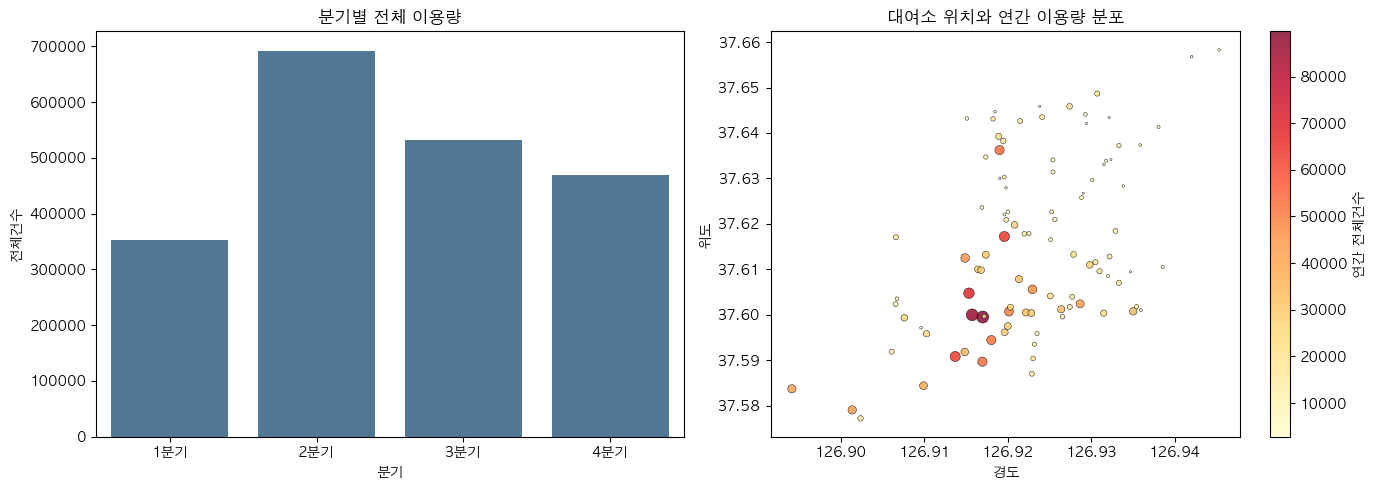

,대여소_ID,주소1,연간_전체건수
0,ST-455,서울특별시 은평구 은평로 85 CJ드림시티,89663
1,ST-2264,서울특별시 은평구 연서로 9 센타폴리스,86113
2,ST-479,서울특별시 은평구 역촌동 45-34,68748
3,ST-454,서울특별시 은평구 대조동 207-8,63942
4,ST-462,서울특별시 은평구 신사동 352-2,63774
5,ST-453,서울특별시 은평구 진관동 86-31,53190
6,ST-460,서울특별시 은평구 응암동 604-5,53017
7,ST-1331,서울특별시 은평구 응암로 247 외환은행,52136
8,ST-461,서울특별시 은평구 응암동 90-15,49751
9,ST-459,서울특별시 은평구 녹번동 153-31,47328


In [14]:
quarter_totals = pd.DataFrame({
    '분기': ['1분기', '2분기', '3분기', '4분기'],
    '전체건수': [
        cluster_df['1분기_전체건수'].sum(),
        cluster_df['2분기_전체건수'].sum(),
        cluster_df['3분기_전체건수'].sum(),
        cluster_df['4분기_전체건수'].sum()
    ]
})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=quarter_totals, x='분기', y='전체건수', color='#457b9d', ax=axes[0])
axes[0].set_title('분기별 전체 이용량')
axes[0].set_xlabel('분기')
axes[0].set_ylabel('전체건수')

scatter = axes[1].scatter(
    cluster_df['경도'],
    cluster_df['위도'],
    s=cluster_df['연간_전체건수'] / 1200,
    c=cluster_df['연간_전체건수'],
    cmap='YlOrRd',
    alpha=0.8,
    edgecolors='black',
    linewidths=0.4
)
axes[1].set_title('대여소 위치와 연간 이용량 분포')
axes[1].set_xlabel('경도')
axes[1].set_ylabel('위도')
fig.colorbar(scatter, ax=axes[1], label='연간 전체건수')

plt.tight_layout()
plt.show()

cluster_df[['대여소_ID', '주소1', '연간_전체건수']].sort_values('연간_전체건수', ascending=False).head(10)

## 3. 군집 수 후보 비교

최종 코드는 `k=10`으로 군집을 나누지만, 바로 10을 고정한 것은 아니다.

여기서는 `k=4`부터 `k=12`까지 비교하면서 다음을 함께 본다.
- `inertia`: 군집 내부 응집도
- `silhouette score`: 군집 간 분리도

실루엣 점수만 보면 `k=11`이 아주 근소하게 높지만, `k=10`도 거의 같은 수준이고 결과 해석과 지도 가독성에서 더 단순하다고 판단해 최종 선택했다.

In [15]:
X = cluster_df[['위도', '경도']]
cluster_eval = []

for k in range(4, 13):
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = model.fit_predict(X)
    cluster_eval.append({
        'k': k,
        'inertia': model.inertia_,
        'silhouette': silhouette_score(X, labels)
    })

cluster_eval_df = pd.DataFrame(cluster_eval)
cluster_eval_df


,k,inertia,silhouette
0,4,0.008138,0.390834
1,5,0.006613,0.402033
2,6,0.005469,0.359018
3,7,0.004427,0.408598
4,8,0.003776,0.398813
5,9,0.003309,0.392431
6,10,0.002824,0.414451
7,11,0.002342,0.415624
8,12,0.002079,0.413530


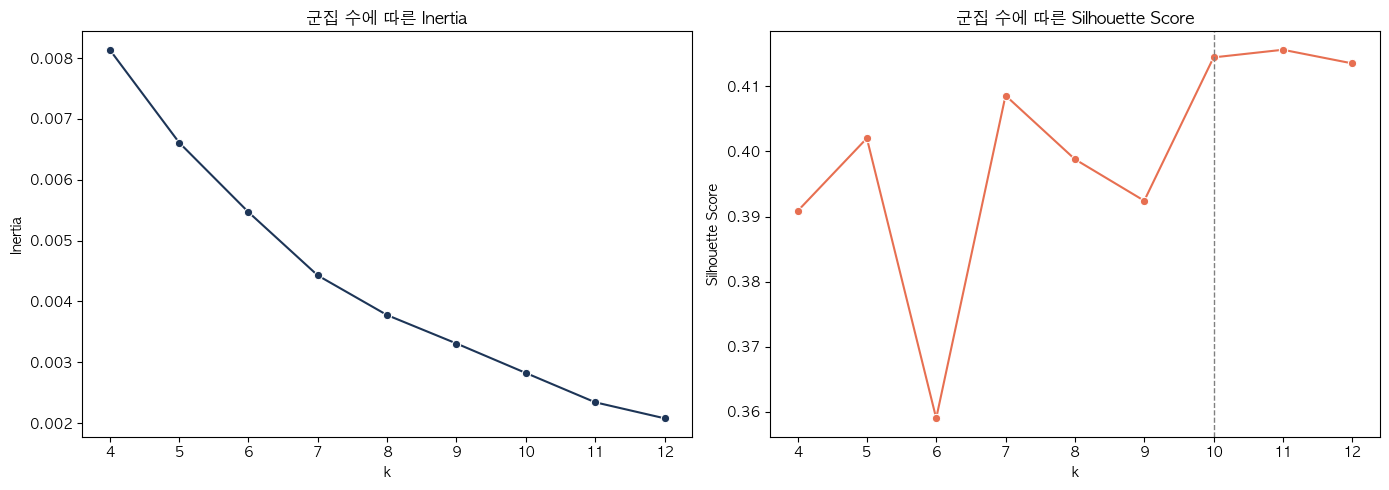

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.lineplot(data=cluster_eval_df, x='k', y='inertia', marker='o', color='#1d3557', ax=axes[0])
axes[0].set_title('군집 수에 따른 Inertia')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Inertia')

sns.lineplot(data=cluster_eval_df, x='k', y='silhouette', marker='o', color='#e76f51', ax=axes[1])
axes[1].axvline(10, color='gray', linestyle='--', linewidth=1)
axes[1].set_title('군집 수에 따른 Silhouette Score')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Silhouette Score')

plt.tight_layout()
plt.show()

## 4. 최종 군집화 코드

아래 셀은 실제 결과물을 만든 최종 코드이다.

- `ST-93` 제외
- `위도`, `경도`만 사용한 `KMeans(n_clusters=10)` 수행
- 군집 번호를 `1~10`으로 정리
- 군집별 요약표 저장
- Folium 지도 저장

In [17]:
import pandas as pd

try:
    import folium
    from sklearn.cluster import KMeans
except ModuleNotFoundError:
    raise ModuleNotFoundError("필요한 패키지가 없습니다. 먼저 `%pip install folium scikit-learn` 을 실행하세요.")

# 1. 집계표 불러오기 및 ST-93 제외
cluster_df = pd.read_csv('./Data/은평_분기별_대여소_집계표.csv')
cluster_df = cluster_df[cluster_df['대여소_ID'] != 'ST-93'].copy()
cluster_df['위도'] = pd.to_numeric(cluster_df['위도'], errors='coerce')
cluster_df['경도'] = pd.to_numeric(cluster_df['경도'], errors='coerce')
cluster_df = cluster_df.dropna(subset=['위도', '경도']).reset_index(drop=True)

# 2. 위경도 기준 10개 군집 생성
X = cluster_df[['위도', '경도']]
kmeans = KMeans(n_clusters=10, random_state=42, n_init=10)
cluster_df['cluster_10'] = kmeans.fit_predict(X)

# 3. 군집 번호를 보기 좋게 1~10으로 변환
cluster_df['cluster_10'] = cluster_df['cluster_10'] + 1
cluster_df = cluster_df.sort_values(['cluster_10', '연간_전체건수'], ascending=[True, False]).reset_index(drop=True)

# 4. 군집별 요약표 생성
cluster_summary = (
    cluster_df.groupby('cluster_10', as_index=False)
    .agg(
        스테이션수=('대여소_ID', 'count'),
        연간전체건수합=('연간_전체건수', 'sum'),
        평균연간건수=('연간_전체건수', 'mean')
    )
    .sort_values('cluster_10')
)

# 5. 결과 저장
cluster_df.to_csv('../Data/은평_ST93제외_10개군집_스테이션분류.csv', index=False, encoding='utf-8-sig')
cluster_summary.to_csv('../Data/은평_ST93제외_10개군집_요약표.csv', index=False, encoding='utf-8-sig')

# 6. 군집 지도 생성
map_center = [cluster_df['위도'].mean(), cluster_df['경도'].mean()]
cluster_map = folium.Map(location=map_center, zoom_start=12, tiles='OpenStreetMap')

cluster_colors = {
    1: '#e41a1c',
    2: '#377eb8',
    3: '#4daf4a',
    4: '#984ea3',
    5: '#ff7f00',
    6: '#ffff33',
    7: '#a65628',
    8: '#f781bf',
    9: '#17becf',
    10: '#999999'
}

for _, row in cluster_df.iterrows():
    cluster_no = int(row['cluster_10'])
    color = cluster_colors[cluster_no]
    popup_text = (
        f"<b>군집:</b> {cluster_no}<br>"
        f"<b>대여소 ID:</b> {row['대여소_ID']}<br>"
        f"<b>주소1:</b> {row['주소1']}<br>"
        f"<b>주소2:</b> {row['주소2']}<br>"
        f"<b>연간 전체건수:</b> {int(row['연간_전체건수']):,}"
    )

    folium.CircleMarker(
        location=[row['위도'], row['경도']],
        radius=5,
        color=color,
        fill=True,
        fill_color=color,
        fill_opacity=0.9,
        weight=1,
        popup=folium.Popup(popup_text, max_width=320),
        tooltip=f"군집 {cluster_no} | {row['대여소_ID']}"
    ).add_to(cluster_map)

legend_html = '''
<div style="position: fixed; bottom: 40px; left: 40px; width: 170px; z-index:9999; background:white; border:2px solid gray; padding:10px; font-size:13px;">
<b>10개 군집</b><br>
<span style="color:#e41a1c;">●</span> 군집 1<br>
<span style="color:#377eb8;">●</span> 군집 2<br>
<span style="color:#4daf4a;">●</span> 군집 3<br>
<span style="color:#984ea3;">●</span> 군집 4<br>
<span style="color:#ff7f00;">●</span> 군집 5<br>
<span style="color:#ffff33;">●</span> 군집 6<br>
<span style="color:#a65628;">●</span> 군집 7<br>
<span style="color:#f781bf;">●</span> 군집 8<br>
<span style="color:#17becf;">●</span> 군집 9<br>
<span style="color:#999999;">●</span> 군집 10
</div>
'''
cluster_map.get_root().html.add_child(folium.Element(legend_html))
cluster_map.save('eunpyeong_station_cluster_10_map.html')

print('저장 완료: ../Data/은평_ST93제외_10개군집_스테이션분류.csv')
print('저장 완료: ../Data/은평_ST93제외_10개군집_요약표.csv')
print('저장 완료: eunpyeong_station_cluster_10_map.html')

cluster_summary

저장 완료: ../Data/은평_ST93제외_10개군집_스테이션분류.csv
저장 완료: ../Data/은평_ST93제외_10개군집_요약표.csv
저장 완료: eunpyeong_station_cluster_10_map.html


,cluster_10,스테이션수,연간전체건수합,평균연간건수
0,1,10,166117,16611.700000
1,2,11,264169,24015.363636
2,3,11,74783,6798.454545
3,4,8,66423,8302.875000
4,5,6,96565,16094.166667
5,6,14,203258,14518.428571
6,7,4,143501,35875.250000
7,8,7,250054,35722.000000
8,9,10,147161,14716.100000
9,10,17,634628,37331.058824


## 5. 결과 해석

이 결과는 **은평구 대여소를 공간적으로 가까운 권역 단위로 먼저 묶어보는 1차 군집화**로 해석할 수 있다.

- 장점: 지도 위에서 생활권 단위 구분이 직관적이다.
- 한계: 이용행태, 버스/지하철 접근성, 주변 시설 정보는 아직 반영하지 않았다.

따라서 이 10군집은 이후 수동 조정이나 시설 반영 군집화의 출발점 역할을 한다.

In [18]:
display(cluster_summary)
display(cluster_df[['대여소_ID', 'cluster_10', '연간_전체건수', '주소1']].head(20))
cluster_map

,cluster_10,스테이션수,연간전체건수합,평균연간건수
0,1,10,166117,16611.700000
1,2,11,264169,24015.363636
2,3,11,74783,6798.454545
3,4,8,66423,8302.875000
4,5,6,96565,16094.166667
5,6,14,203258,14518.428571
6,7,4,143501,35875.250000
7,8,7,250054,35722.000000
8,9,10,147161,14716.100000
9,10,17,634628,37331.058824


,대여소_ID,cluster_10,연간_전체건수,주소1
0,ST-453,1,53190,서울특별시 은평구 진관동 86-31
1,ST-1483,1,23414,서울특별시 은평구 진관2로 15-46
2,ST-1481,1,18332,서울특별시 은평구 진관2로 지하 15-25
3,ST-1329,1,15634,서울특별시 은평구 진관3로 77
4,ST-2244,1,15384,서울특별시 은평구 진관4로 26 진관고등학교
5,ST-450,1,12763,서울특별시 은평구 진관동 45-21
6,ST-3058,1,11869,서울특별시 은평구 진관동 91-10
7,ST-1480,1,7678,서울특별시 은평구 진관동 29-2
8,ST-1024,1,4594,서울특별시 은평구 진관동 44-28
9,ST-1023,1,3259,서울특별시 은평구 진관동 30-23


## 6. 지형 경계를 반영한 수동 보정

위의 10개 군집은 `위도`와 `경도`만 이용한 **기초 공간 군집화** 결과이다. 다만 실제 은평구 생활권은 단순 직선거리만으로 설명되지 않는 구간이 있다.

특히 다음과 같은 **물리적 경계**는 대여소 간 연결성을 약하게 만들 수 있다.
- 불광천과 진관천 같은 하천 축
- 북한산 자락과 산지 경계
- 큰 간선도로와 단절된 블록 구조

즉 지도상으로는 가까워 보여도, 실제 이용 흐름이나 생활권은 다른 군집으로 읽히는 대여소가 존재한다. 그래서 자동 군집 결과를 그대로 확정하지 않고, 현장 해석이 필요한 대여소를 별도 군집으로 재배치했다.

### 6-1. 수동 보정 원칙

수동 보정은 다음 원칙으로 진행했다.

1. 자동 군집 결과를 기본값으로 둔다.
2. 하천, 산지, 생활권 경계 때문에 분리해서 봐야 하는 대여소만 별도 조정한다.
3. 새로 묶인 군집은 해석 가능한 권역 단위가 되도록 만든다.

이번 보정에서는 특히 다음 두 묶음을 새로운 군집으로 분리했다.
- `군집 11`: `ST-2259`, `ST-2260`
- `군집 12`: `ST-2779`, `ST-455`, `ST-2264`, `ST-2257`, `ST-463`, `ST-1034`, `ST-462`

또한 `ST-476`은 지형과 생활권 해석상 `군집 3`으로 편입했다.

### 6-2. 수동 보정 코드와 의미

아래 코드는 기존 `10개 군집` 결과를 불러와서, 일부 대여소를 `11번`과 `12번` 군집으로 재배치하는 과정이다.

- `cluster_10`은 자동 군집 결과
- `cluster_12_custom`은 지형 경계를 반영해 수정한 최종 군집 결과

이 단계에서 중요한 점은, **군집화 알고리즘이 직접 찾지 못한 생활권 단절 요소를 사람이 해석해서 보정했다는 것**이다. 따라서 이 결과는 완전 자동 군집이 아니라, 공간 군집을 바탕으로 한 `해석 기반 군집화`에 가깝다.

## 7. 최종 군집 시각화

아래 시각화는 지형 경계와 생활권 해석을 반영해 최종적으로 확정한 군집 결과이다.

- 입력 파일: `Data/은평구_스테이션_군집화_1차.csv`
- 사용 군집 번호: `cluster_12_custom`
- 결과는 `전체 지도`와 `권역 경계 지도`를 함께 확인한다.
- 권역 외곽선은 각 군집 스테이션 좌표의 convex hull 기준으로 표시한다.

In [1]:
from pathlib import Path

import folium
import pandas as pd
from IPython.display import display
from scipy.spatial import ConvexHull, QhullError

candidate_paths = [
    Path('./Data/은평구_스테이션_군집화_1차.csv'),
    Path('../Data/은평구_스테이션_군집화_1차.csv'),
    Path('../../Data/은평구_스테이션_군집화_1차.csv'),
    Path('../../../Data/은평구_스테이션_군집화_1차.csv')
]
data_path = next((path for path in candidate_paths if path.exists()), None)
if data_path is None:
    raise FileNotFoundError('은평구 군집 결과 파일을 찾을 수 없습니다.')

final_cluster_df = pd.read_csv(data_path).copy()
final_cluster_df = final_cluster_df.drop(columns=['Unnamed: 0'], errors='ignore')
final_cluster_df['cluster_12_custom'] = final_cluster_df['cluster_12_custom'].astype(int)
final_cluster_df = final_cluster_df.sort_values(['cluster_12_custom', '연간_전체건수'], ascending=[True, False]).reset_index(drop=True)

final_cluster_summary = (
    final_cluster_df.groupby('cluster_12_custom', as_index=False)
    .agg(
        스테이션수=('대여소_ID', 'count'),
        연간전체건수합=('연간_전체건수', 'sum'),
        평균연간건수=('연간_전체건수', 'mean')
    )
    .sort_values('cluster_12_custom')
    .reset_index(drop=True)
)

final_cluster_colors = {
    1: '#e41a1c',
    2: '#377eb8',
    3: '#4daf4a',
    4: '#984ea3',
    5: '#ff7f00',
    6: '#ffd166',
    7: '#a65628',
    8: '#f781bf',
    9: '#17becf',
    10: '#999999',
    11: '#4361ee',
    12: '#6a4c93'
}

bounds = final_cluster_df[['위도', '경도']].agg(['min', 'max'])
map_bounds = [
    [bounds.loc['min', '위도'], bounds.loc['min', '경도']],
    [bounds.loc['max', '위도'], bounds.loc['max', '경도']]
]

def add_cluster_boundary(map_obj, group_df, color):
    points = group_df[['경도', '위도']].drop_duplicates().to_numpy()

    if len(points) >= 3:
        try:
            hull = ConvexHull(points)
            hull_points = points[hull.vertices]
            polygon_coords = [[lat, lon] for lon, lat in hull_points]
            folium.Polygon(
                locations=polygon_coords,
                color=color,
                weight=2,
                fill=True,
                fill_color=color,
                fill_opacity=0.12,
                tooltip=f'군집 {int(group_df.iloc[0]["cluster_12_custom"])} 권역'
            ).add_to(map_obj)
            return
        except QhullError:
            pass

    if len(points) == 2:
        folium.PolyLine(
            locations=[[lat, lon] for lon, lat in points],
            color=color,
            weight=3,
            opacity=0.8,
            tooltip=f'군집 {int(group_df.iloc[0]["cluster_12_custom"])} 권역'
        ).add_to(map_obj)

overview_map = folium.Map(
    location=[final_cluster_df['위도'].mean(), final_cluster_df['경도'].mean()],
    tiles='CartoDB positron',
    zoom_start=12
)

cluster_boundary_map = folium.Map(
    location=[final_cluster_df['위도'].mean(), final_cluster_df['경도'].mean()],
    tiles='CartoDB positron',
    zoom_start=12
)

for _, row in final_cluster_df.iterrows():
    cluster_no = int(row['cluster_12_custom'])
    color = final_cluster_colors[cluster_no]
    popup_text = (
        f"<b>최종 군집:</b> {cluster_no}<br>"
        f"<b>대여소 ID:</b> {row['대여소_ID']}<br>"
        f"<b>주소1:</b> {row['주소1']}<br>"
        f"<b>주소2:</b> {row['주소2'] if pd.notna(row['주소2']) else ''}<br>"
        f"<b>연간 전체건수:</b> {int(row['연간_전체건수']):,}"
    )

    folium.CircleMarker(
        location=[row['위도'], row['경도']],
        radius=5,
        color=color,
        fill=True,
        fill_color=color,
        fill_opacity=0.85,
        weight=1,
        popup=folium.Popup(popup_text, max_width=320),
        tooltip=f"군집 {cluster_no} | {row['대여소_ID']}"
    ).add_to(overview_map)

    folium.CircleMarker(
        location=[row['위도'], row['경도']],
        radius=6,
        color=color,
        fill=True,
        fill_color=color,
        fill_opacity=0.95,
        weight=1,
        popup=folium.Popup(popup_text, max_width=320),
        tooltip=f"군집 {cluster_no} | {row['대여소_ID']}"
    ).add_to(cluster_boundary_map)

for cluster_no, group_df in final_cluster_df.groupby('cluster_12_custom'):
    add_cluster_boundary(cluster_boundary_map, group_df, final_cluster_colors[int(cluster_no)])

legend_html = ['<div style="position: fixed; bottom: 40px; left: 40px; width: 190px; z-index:9999; background:white; border:2px solid gray; padding:10px; font-size:13px;">', '<b>최종 12개 권역</b><br>']
for cluster_no in sorted(final_cluster_colors):
    legend_html.append(f"<span style='color:{final_cluster_colors[cluster_no]};'>●</span> 군집 {cluster_no}<br>")
legend_html.append('</div>')

overview_map.get_root().html.add_child(folium.Element(''.join(legend_html)))
cluster_boundary_map.get_root().html.add_child(folium.Element(''.join(legend_html)))
overview_map.fit_bounds(map_bounds)
cluster_boundary_map.fit_bounds(map_bounds)

display(final_cluster_summary)
display(overview_map)
display(cluster_boundary_map)


,cluster_12_custom,스테이션수,연간전체건수합,평균연간건수
0,1,10,166117,16611.700000
1,2,11,264169,24015.363636
2,3,12,80835,6736.250000
3,4,5,51899,10379.800000
4,5,6,96565,16094.166667
5,6,14,203258,14518.428571
6,7,2,86058,43029.000000
7,8,7,250054,35722.000000
8,9,10,147161,14716.100000
9,10,12,348200,29016.666667


In [20]:
manual_adjustment_summary = pd.DataFrame({
    '구분': ['자동 군집 기본값', '신규 군집 11', '신규 군집 12', '기존 군집 편입'],
    '설명': [
        '기존 KMeans 10군집 결과를 출발점으로 사용',
        'ST-2259, ST-2260을 별도 권역으로 분리',
        'ST-2779, ST-455, ST-2264, ST-2257, ST-463, ST-1034, ST-462를 별도 권역으로 재구성',
        'ST-476을 군집 3으로 편입'
    ]
})

manual_adjustment_summary

,구분,설명
0,자동 군집 기본값,기존 KMeans 10군집 결과를 출발점으로 사용
1,신규 군집 11,"ST-2259, ST-2260을 별도 권역으로 분리"
2,신규 군집 12,"ST-2779, ST-455, ST-2264, ST-2257, ST-463, ST-..."
3,기존 군집 편입,ST-476을 군집 3으로 편입
